# FinAccess 2024 Project Notebook

This is the one notebook I will use for the project.

The goal is to predict whether an adult in Kenya is **Excluded**, **Mobile money only**, or **Banked** using a small set of social and economic features from the FinAccess 2024 survey.

In this notebook, I will do six main things.

1. Load and clean the survey data
2. Define the adult analytic sample and explain the target clearly
3. Use weighted descriptive analysis to understand the data better
4. Train and compare a few beginner friendly machine learning models
5. Check interpretation, subgroup performance, and one robustness test
6. Save the final outputs for the app and report


## Why this version is still simple

I want the notebook to feel like something I can actually learn from.

So even though this is a master's level project, I am keeping the code readable. That means I am not using every advanced technique I could possibly use. Instead, I am adding the pieces that make the project more defensible without making the notebook hard to follow.


In [1]:
import warnings

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
        


## Load the survey data and build the target

I am only loading the columns I actually plan to use. This keeps the notebook faster and easier to understand.

I am also loading `indWeight` because I want my descriptive summaries to reflect the survey design more honestly.


In [2]:
# Set up folders for anything I want to save.
artifact_dir = Path('artifacts')
artifact_dir.mkdir(exist_ok=True)

figure_dir = Path('figures')
figure_dir.mkdir(exist_ok=True)

# These are the raw survey columns I want to use.
column_map = {
    'county': 'county',
    'Sex': 'sex',
    'A18': 'age_years',
    'NHM': 'household_size',
    'A20': 'education',
    'A21': 'marital_status',
    'A22i': 'children_in_household',
    'livelihoodcat': 'livelihood',
    'S2__1': 'can_access_internet',
    'S3': 'internet_frequency',
    'nfh_categories': 'financial_health',
    'C1_10': 'mobile_money_use',
    'C1_12': 'bank_use',
    'indWeight': 'indWeight'
}

numeric_hard_bounds = {
    'age_years': (18, 105),
    'household_size': (1, 20),
    'children_in_household': (0, 19)
}

data_path = '2024_Finaccess_Publicdata.dta'

# Read only the columns we need, then rename them to clearer names.
df = pd.read_stata(
    data_path,
    convert_categoricals=False,
    columns=list(column_map.keys())
).rename(columns=column_map)

# Remove rows where the key current-use responses are coded as unknown.
data = df[(df['mobile_money_use'] != 9) & (df['bank_use'] != 9)].copy()

# Turn a few special survey codes into missing values.
data['education'] = data['education'].replace([98, 99], np.nan)
data['marital_status'] = data['marital_status'].replace([98, 99], np.nan)
data['internet_frequency'] = data['internet_frequency'].replace([6, 7], np.nan)

# Build the project target from current mobile money and bank use.
mobile_now = data['mobile_money_use'] == 1
bank_now = data['bank_use'] == 1

data['financial_access_profile'] = np.select(
    [~mobile_now & ~bank_now, mobile_now & ~bank_now],
    ['Excluded', 'Mobile money only'],
    default='Banked'
)

# These are the features I want to keep for the models.
selected_features = [
    'county',
    'sex',
    'age_years',
    'household_size',
    'education',
    'marital_status',
    'children_in_household',
    'livelihood',
    'can_access_internet',
    'internet_frequency',
    'financial_health'
]

# Keep a full version for robustness work and an adult version for the main analysis.
full_model_data = data[selected_features + ['indWeight', 'financial_access_profile']].copy()
adult_model_data = full_model_data[full_model_data['age_years'] >= 18].copy()

# Treat impossible numeric values as missing before modeling.
for feature, (hard_min, hard_max) in numeric_hard_bounds.items():
    adult_model_data.loc[
        (adult_model_data[feature] < hard_min) | (adult_model_data[feature] > hard_max),
        feature
    ] = np.nan

print('Rows in the full cleaned sample:', len(full_model_data))
print('Rows in the adult 18+ sample:', len(adult_model_data))
print('Rows below age 18 removed from the main analysis:', len(full_model_data) - len(adult_model_data))
adult_model_data.head()
        


Rows in the full cleaned sample: 20862
Rows in the adult 18+ sample: 19741
Rows below age 18 removed from the main analysis: 1121


,county,sex,age_years,household_size,education,marital_status,children_in_household,livelihood,can_access_internet,internet_frequency,financial_health,indWeight,financial_access_profile
0,7,2,29.0,5.0,7.0,4.0,1.0,5,1.0,1.0,2,425.383057,Banked
1,7,2,60.0,11.0,1.0,4.0,8.0,6,0.0,5.0,3,28.772942,Mobile money only
2,40,2,35.0,2.0,3.0,2.0,5.0,3,0.0,5.0,2,171.933701,Mobile money only
3,22,1,24.0,1.0,4.0,1.0,0.0,3,0.0,2.0,3,667.667114,Mobile money only
4,21,2,20.0,1.0,6.0,1.0,0.0,5,1.0,1.0,1,331.741516,Banked


## How to read the target and the main sample

The target is built directly from two FinAccess current-use variables:

- `C1_10` = current mobile money use
- `C1_12` = current bank use

I first remove rows where either variable is coded as unknown (`9`). Then I define the three classes as follows:

- **Excluded**: `C1_10 != 1` and `C1_12 != 1`
- **Mobile money only**: `C1_10 == 1` and `C1_12 != 1`
- **Banked**: `C1_12 == 1`, whether or not `C1_10 == 1`

The survey includes some respondents below age 18, but I am making **18 and above** the main analytic sample. That choice makes sense for this project because formal financial access, especially bank-based access, is more closely tied to adulthood and to the practical requirements around identification and account ownership.

So yes, the **Banked** class includes some dual users. I am making that choice on purpose because this project is asking whether a person has bank-based financial access, not whether they use banks in isolation.

This is also a narrower **core rails access profile**, not a complete reproduction of every broader FinAccess concept of financial inclusion.
        


## Why I chose these 11 features

The public survey has more than 3,800 fields, so I am not modeling the full file directly. My target modeling space is a small set of interpretable predictors, roughly **10-20 variables**, and the current notebook uses **11 features**.

I screened features using survey documentation and practical relevance:

- keep variables that describe place, demographics, household structure, digital access, or broad financial condition
- drop fields with very high missingness, especially around **40-50% or more**, unless they are clearly essential
- exclude leakage-prone current-access variables such as `C1_10`, `C1_12`, current primary financial provider, or other current-use indicators
- avoid carrying large multi-select survey batteries into the final model as dozens or hundreds of dummy variables unless they can be summarized meaningfully

The 11 columns below give a simple but useful picture of financial access in Kenya.

- **County** gives local context.
- **Sex, age, marital status, and household structure** describe the person and household.
- **Education** helps capture differences in opportunity and literacy.
- **Livelihood** gives economic context.
- **Internet access and internet frequency** matter because digital access is closely tied to mobile money and formal finance.
- **Financial health** gives a broad summary of the respondent's financial situation.
        


## Weighted target distribution for the adult sample

The survey includes an individual weight called `indWeight`. I want to use that in the descriptive sections so the percentages better reflect the survey design.

I will show both the raw sample distribution and the weighted percentage distribution for the **adult 18+ sample**, since that is the main analysis sample.


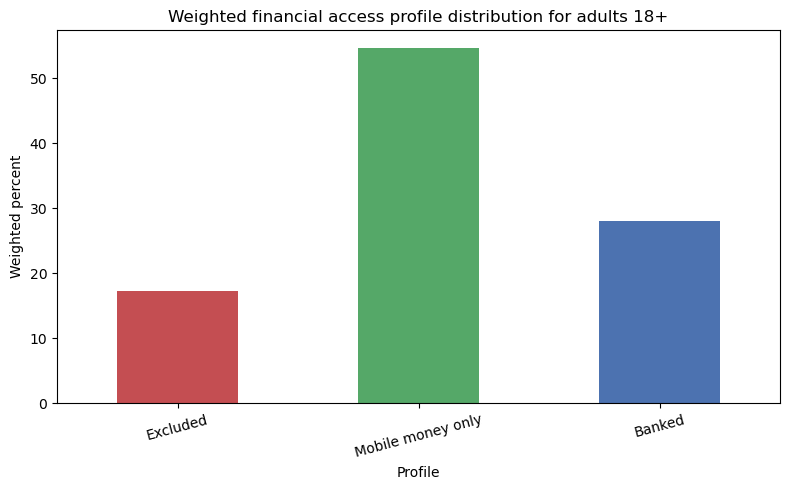

In [3]:
# Build both unweighted and weighted summaries of the target for adults only.
sample_counts = adult_model_data['financial_access_profile'].value_counts()
sample_percent = adult_model_data['financial_access_profile'].value_counts(normalize=True).mul(100)
weighted_percent = adult_model_data.groupby('financial_access_profile')['indWeight'].sum()
weighted_percent = weighted_percent.div(weighted_percent.sum()).mul(100)

target_summary = pd.DataFrame({
    'sample_count': sample_counts,
    'sample_percent': sample_percent.round(2),
    'weighted_percent': weighted_percent.round(2)
}).reindex(['Excluded', 'Mobile money only', 'Banked'])

target_summary

# Plot the weighted percentages because they better reflect the survey design.
plt.figure(figsize=(8, 5))
target_summary['weighted_percent'].plot(kind='bar', color=['#C44E52', '#55A868', '#4C72B0'])
plt.title('Weighted financial access profile distribution for adults 18+')
plt.xlabel('Profile')
plt.ylabel('Weighted percent')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(figure_dir / 'weighted_target_distribution_adults.png', dpi=200)
plt.show()


## Why weights matter here

The descriptive charts in this notebook are meant to say something about the population, not only about the raw sample that happened to be interviewed. That is why I am using `indWeight` in the EDA.

For the prediction models, I am keeping the workflow unweighted. That choice is intentional. A full survey-weighted machine learning pipeline would add a lot more complexity, and my main modeling goal is predictive performance at the respondent level. So I will treat the EDA as weighted and representative, while I will treat the model as an unweighted predictive exercise.


## A quick note on class imbalance

The classes are not perfectly balanced, and that matters.

If I only looked at plain accuracy, a model could look good mainly by performing well on the largest class. That is why I am also using **balanced accuracy** and especially **macro F1 score**. Macro F1 gives equal attention to all three classes, which is more fair for this project.

To handle imbalance, I use **stratified train/test splitting** and **stratified cross-validation** so each class stays represented throughout the workflow. I also compare standard models with **class-weighted** versions of logistic regression and random forest. I am not using **SMOTE** in the main notebook because most predictors are categorical survey variables, so synthetic rows could create unrealistic combinations.
        


## Missing-data strategy in the adult sample

I handle missingness explicitly rather than treating it generically.

- Known nonresponse codes are converted to missing first, including `98`, `99`, and the internet-frequency codes `6` and `7`.
- Numeric variables are median-imputed in the preprocessing pipeline.
- Categorical variables are filled with the most common category in the preprocessing pipeline.
- Variables with very high missingness would be dropped earlier in feature screening if they were not essential to the project.
        


In [4]:
# Show the percentage of missing values in each selected feature.
missing_summary = adult_model_data[selected_features].isna().mean().mul(100).round(2).sort_values(ascending=False)
high_missing_selected = missing_summary[missing_summary > 40]

missing_summary.to_frame(name='missing_percent')

if high_missing_selected.empty:
    print('No selected feature exceeds the 40% missingness screen in the adult sample.')
else:
    print('Selected features above the 40% missingness screen:')
    high_missing_selected.to_frame(name='missing_percent')
        


No selected feature exceeds the 40% missingness screen in the adult sample.


## Numeric outlier review and numeric-only correlation checks

For numeric variables such as age, household size, and number of children, I review summary statistics, IQR fences, histograms, and boxplots before modeling. I also use questionnaire-aligned hard bounds as a safety check:

- age: **18-105**
- household size: **1-20**
- children in household: **0-19**

Values outside those survey bounds are treated as missing. I also use a simple correlation heatmap for **numeric variables only**, because correlation plots are not meaningful for the one-hot encoded categorical fields.
                


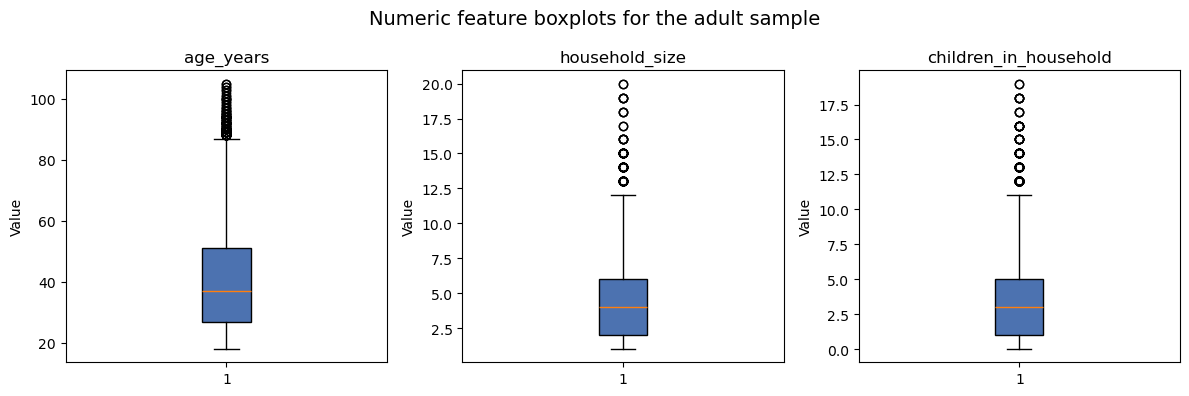

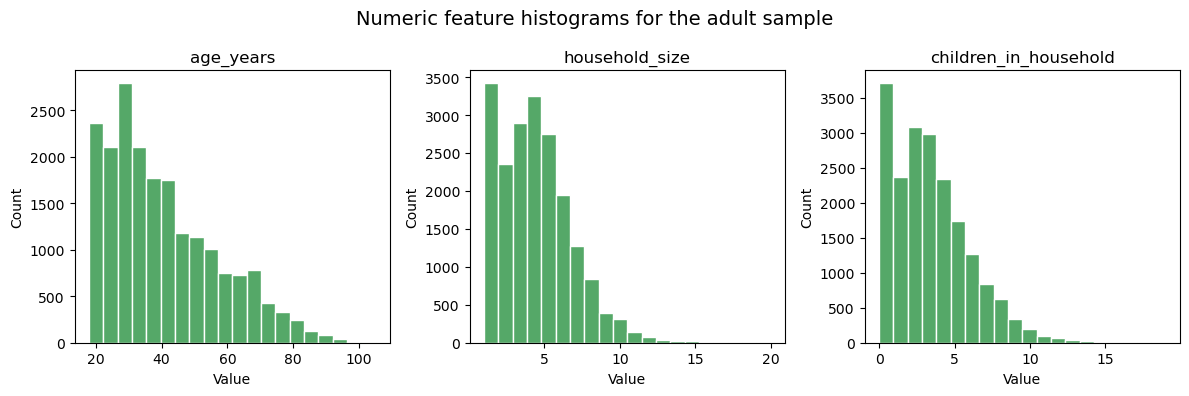

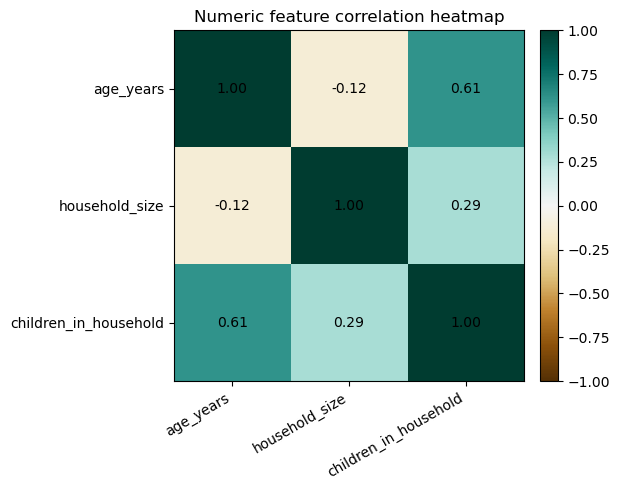

In [5]:
review_features = ['age_years', 'household_size', 'children_in_household']

def build_numeric_review(df):
    rows = []
    for feature in review_features:
        series = df[feature].dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr
        hard_min, hard_max = numeric_hard_bounds[feature]

        rows.append({
            'feature': feature,
            'min': round(series.min(), 2),
            'q1': round(q1, 2),
            'median': round(series.median(), 2),
            'q3': round(q3, 2),
            'max': round(series.max(), 2),
            'iqr': round(iqr, 2),
            'lower_fence': round(lower_fence, 2),
            'upper_fence': round(upper_fence, 2),
            'below_iqr_fence_count': int((series < lower_fence).sum()),
            'above_iqr_fence_count': int((series > upper_fence).sum()),
            'hard_min': hard_min,
            'hard_max': hard_max,
            'outside_hard_bounds_count': int(((series < hard_min) | (series > hard_max)).sum())
        })
    return pd.DataFrame(rows)

numeric_review = build_numeric_review(adult_model_data)
numeric_review

fig, axes = plt.subplots(1, len(review_features), figsize=(12, 4))
for ax, feature in zip(axes, review_features):
    ax.boxplot(adult_model_data[feature].dropna(), patch_artist=True, boxprops={'facecolor': '#4C72B0'})
    ax.set_title(feature)
    ax.set_ylabel('Value')
fig.suptitle('Numeric feature boxplots for the adult sample', fontsize=14)
fig.tight_layout()
plt.savefig(figure_dir / 'numeric_boxplots_adults.png', dpi=200)
plt.show()

fig, axes = plt.subplots(1, len(review_features), figsize=(12, 4))
for ax, feature in zip(axes, review_features):
    ax.hist(adult_model_data[feature].dropna(), bins=20, color='#55A868', edgecolor='white')
    ax.set_title(feature)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
fig.suptitle('Numeric feature histograms for the adult sample', fontsize=14)
fig.tight_layout()
plt.savefig(figure_dir / 'numeric_histograms_adults.png', dpi=200)
plt.show()

numeric_corr = adult_model_data[review_features].corr().round(3)
numeric_corr

fig, ax = plt.subplots(figsize=(6, 5))
heat = ax.imshow(numeric_corr.values, cmap='BrBG', vmin=-1, vmax=1)
ax.set_xticks(range(len(review_features)))
ax.set_yticks(range(len(review_features)))
ax.set_xticklabels(review_features, rotation=30, ha='right')
ax.set_yticklabels(review_features)

for i in range(len(review_features)):
    for j in range(len(review_features)):
        ax.text(j, i, f'{numeric_corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')

ax.set_title('Numeric feature correlation heatmap')
fig.colorbar(heat, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.savefig(figure_dir / 'numeric_correlation_heatmap_adults.png', dpi=200)
plt.show()
                


## Weighted EDA helper

I am going to reuse a small helper function for the next few tables. It builds weighted percentages within each group, which keeps the code shorter and easier to read.


In [6]:
# Build a reusable helper for weighted profile tables.
def weighted_profile_table(df, group_col):
    table = df.groupby([group_col, 'financial_access_profile'])['indWeight'].sum().unstack(fill_value=0)
    table = table.div(table.sum(axis=1), axis=0).mul(100)
    return table.reindex(columns=['Excluded', 'Mobile money only', 'Banked']).round(2)

# Try to pull county labels from the Stata metadata; if that is not available,
# fall back to readable code strings so the notebook still runs.
try:
    import pyreadstat

    _, meta = pyreadstat.read_dta(data_path, metadataonly=True)
    county_label_set = meta.variable_to_label.get('county')
    county_labels = meta.value_labels[county_label_set]
except ModuleNotFoundError:
    county_labels = {value: f'County code {int(value)}' for value in sorted(adult_model_data['county'].dropna().unique())}

# Simple label maps for the charts below.
sex_labels = {1: 'Male', 2: 'Female'}
education_labels = {
    1: 'None',
    2: 'Some primary',
    3: 'Primary completed',
    4: 'Some secondary',
    5: 'Secondary completed',
    6: 'Some technical',
    7: 'Completed technical',
    8: 'Some university',
    9: 'University completed',
    10: 'Other'
}
internet_labels = {0.0: 'No internet access', 1.0: 'Can access internet'}
financial_health_labels = {1: 'High', 2: 'Medium', 3: 'Low'}
class_labels = ['Excluded', 'Mobile money only', 'Banked']
        


## Weighted EDA by sex and education

These are two straightforward ways to see whether financial access differs across people and households.

I am using weights here because I want the percentages to better reflect the broader population represented by the survey.


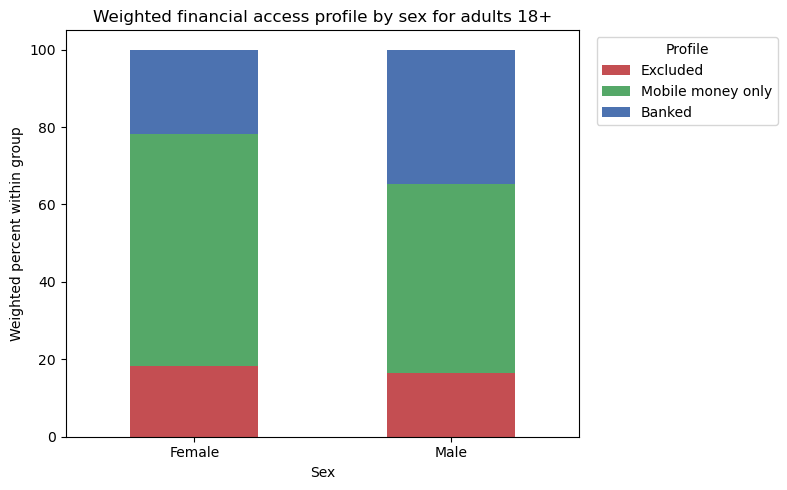

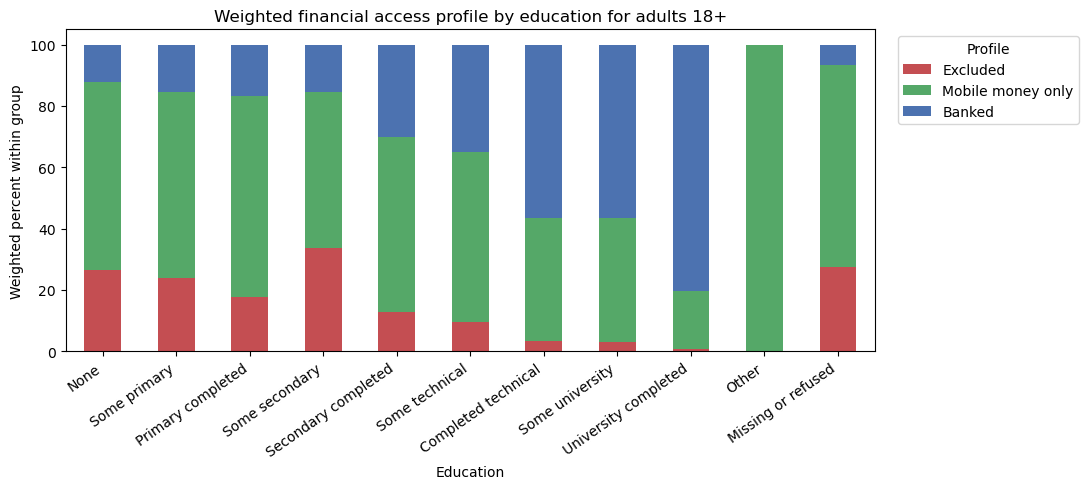

In [7]:
# Build weighted profile tables for sex and education.
eda_data = adult_model_data.copy()
eda_data['sex_label'] = eda_data['sex'].map(sex_labels).fillna('Other or missing')
eda_data['education_label'] = eda_data['education'].map(education_labels).fillna('Missing or refused')

sex_profile = weighted_profile_table(eda_data, 'sex_label')
sex_profile

education_profile = weighted_profile_table(eda_data, 'education_label')
education_order = [
    'None', 'Some primary', 'Primary completed', 'Some secondary',
    'Secondary completed', 'Some technical', 'Completed technical',
    'Some university', 'University completed', 'Other', 'Missing or refused'
]
education_profile = education_profile.reindex([label for label in education_order if label in education_profile.index])
education_profile

# Plot weighted profile by sex.
sex_profile.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=['#C44E52', '#55A868', '#4C72B0']
)
plt.title('Weighted financial access profile by sex for adults 18+')
plt.xlabel('Sex')
plt.ylabel('Weighted percent within group')
plt.xticks(rotation=0)
plt.legend(title='Profile', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(figure_dir / 'weighted_profile_by_sex_adults.png', dpi=200)
plt.show()

# Plot weighted profile by education.
education_profile.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 5),
    color=['#C44E52', '#55A868', '#4C72B0']
)
plt.title('Weighted financial access profile by education for adults 18+')
plt.xlabel('Education')
plt.ylabel('Weighted percent within group')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Profile', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(figure_dir / 'weighted_profile_by_education_adults.png', dpi=200)
plt.show()


## Weighted EDA by internet access and financial health

These two views are useful because they connect directly to the story of digital and financial inclusion.


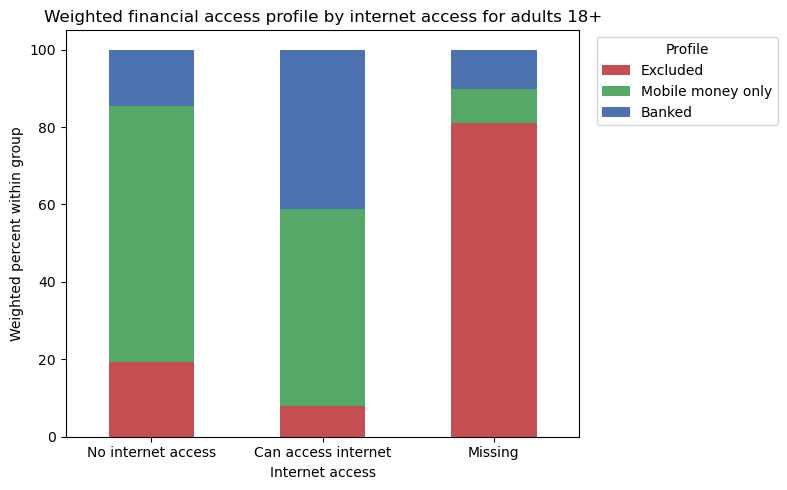

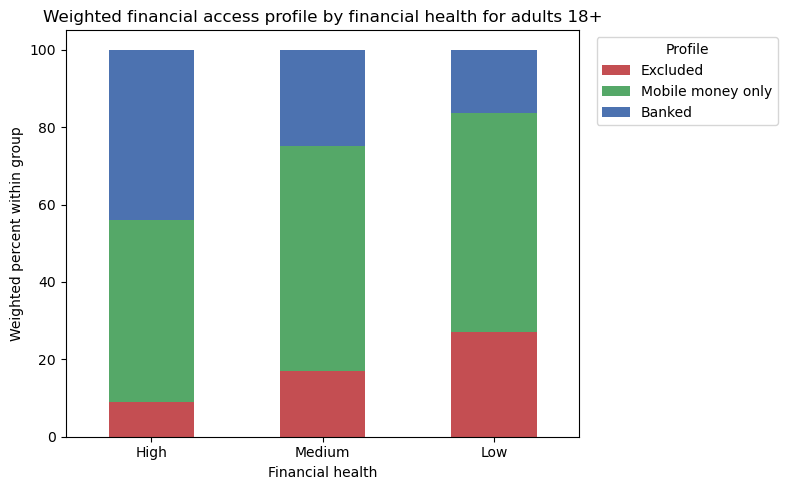

In [8]:
# Build weighted profile tables for internet access and financial health.
eda_data['internet_label'] = eda_data['can_access_internet'].map(internet_labels).fillna('Missing')
eda_data['financial_health_label'] = eda_data['financial_health'].map(financial_health_labels).fillna('Missing')

internet_profile = weighted_profile_table(eda_data, 'internet_label')
internet_profile = internet_profile.reindex([label for label in ['No internet access', 'Can access internet', 'Missing'] if label in internet_profile.index])
internet_profile

health_profile = weighted_profile_table(eda_data, 'financial_health_label')
health_profile = health_profile.reindex([label for label in ['High', 'Medium', 'Low', 'Missing'] if label in health_profile.index])
health_profile

# Plot weighted profile by internet access.
internet_profile.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=['#C44E52', '#55A868', '#4C72B0']
)
plt.title('Weighted financial access profile by internet access for adults 18+')
plt.xlabel('Internet access')
plt.ylabel('Weighted percent within group')
plt.xticks(rotation=0)
plt.legend(title='Profile', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(figure_dir / 'weighted_profile_by_internet_adults.png', dpi=200)
plt.show()

# Plot weighted profile by financial health.
health_profile.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=['#C44E52', '#55A868', '#4C72B0']
)
plt.title('Weighted financial access profile by financial health for adults 18+')
plt.xlabel('Financial health')
plt.ylabel('Weighted percent within group')
plt.xticks(rotation=0)
plt.legend(title='Profile', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(figure_dir / 'weighted_profile_by_financial_health_adults.png', dpi=200)
plt.show()


## Weighted county view

The EDA visuals in this notebook include weighted bar charts by sex, education, internet access, and financial health, plus this county-level view and the numeric-only diagnostics above. For place, I use a ranked county bar chart rather than a geographic heatmap because this notebook does not include county boundary files.

Here I am looking at the counties with the highest weighted share of adults in the **Excluded** group.
        


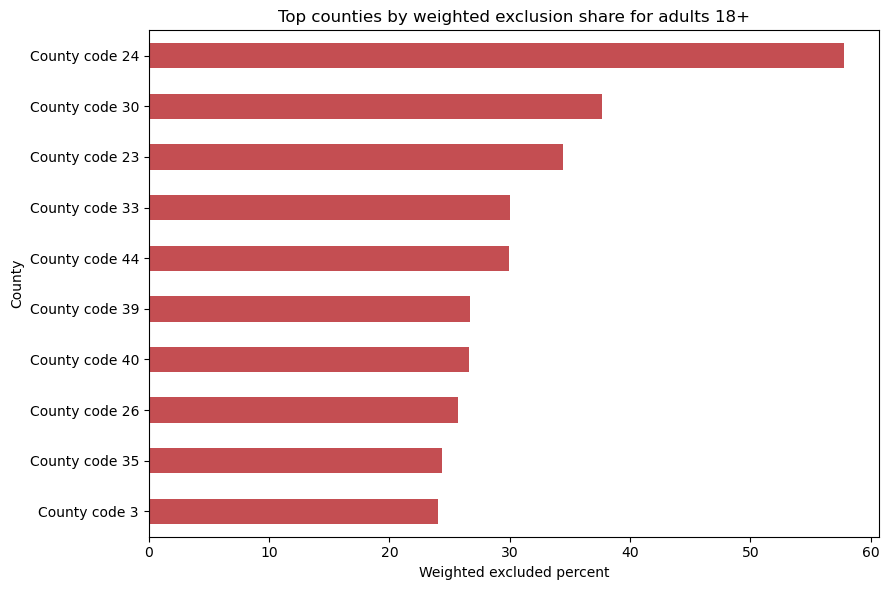

In [9]:
# Build a county-level weighted profile table and keep the counties with the highest exclusion share.
eda_data['county_name'] = eda_data['county'].map(county_labels).fillna(eda_data['county'].astype(str))
county_profile = weighted_profile_table(eda_data, 'county_name')

top_excluded_counties = county_profile['Excluded'].sort_values(ascending=False).head(10).sort_values()
top_excluded_counties.to_frame(name='weighted_excluded_percent')

plt.figure(figsize=(9, 6))
top_excluded_counties.plot(kind='barh', color='#C44E52')
plt.title('Top counties by weighted exclusion share for adults 18+')
plt.xlabel('Weighted excluded percent')
plt.ylabel('County')
plt.tight_layout()
plt.savefig(figure_dir / 'weighted_top_excluded_counties_adults.png', dpi=200)
plt.show()


## Prepare the modeling data for the adult sample

Now I am splitting the work into features and target.

I am also doing an **80 20 train test split** with stratification. Stratification matters because I want the class balance in the training set and test set to stay similar.


In [10]:
# Separate the inputs and the target for the main adult sample.
X = adult_model_data[selected_features].copy()
y = adult_model_data['financial_access_profile'].copy()

# Tell the notebook which columns are categorical and which are numeric.
categorical_features = [
    'county',
    'sex',
    'education',
    'marital_status',
    'livelihood',
    'can_access_internet',
    'internet_frequency',
    'financial_health'
]

numeric_features = ['age_years', 'household_size', 'children_in_household']
class_labels = ['Excluded', 'Mobile money only', 'Banked']

# Keep one honest test set aside from the start.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
        


Training rows: 15792
Test rows: 3949


## Build one simple preprocessing step

I handle variables according to meaning rather than forcing one rule on everything.

- Categorical predictors are imputed with the most common value and then one-hot encoded.
- Numeric predictors stay numeric and use median imputation.
- Although some survey variables have an apparent order, I am not using ordinal encoding in this notebook because I do not want to impose unsupported distances across categories.
- If a category were extremely sparse, I would collapse rare levels before modeling, but that was not necessary for this final 11-feature set.

I am using **one shared preprocessor** for all models so the comparison stays fair and the code stays simple.
        


In [11]:
# This preprocessor returns a dense matrix, which keeps the model code simpler later.
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]),
            categorical_features
        ),
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numeric_features
        )
    ]
)


## Compare models with cross validation, class-weighted baselines, and a tuned gradient boosting model

I do not want to rely on only one train/test split when choosing the model. That can be a little shaky.

So I use **5-fold stratified cross-validation** on the training data first. After that, I still check the chosen models on the held-out test set.

The baseline comparison includes logistic regression, class-weighted logistic regression, random forest, class-weighted random forest, and scikit-learn's **`GradientBoostingClassifier`**. After the baseline comparison, I run a small **`RandomizedSearchCV`** pass on Gradient Boosting instead of a large exhaustive search. This keeps training manageable while still making the tuning step explicit.
        


In [12]:
def evaluate_pipeline(model_name, pipeline, X_train, X_test, y_train, y_test, cv):
    scoring = {
        'accuracy': 'accuracy',
        'balanced_accuracy': 'balanced_accuracy',
        'macro_f1': 'f1_macro'
    }

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    class_recalls = recall_score(
        y_test,
        predictions,
        labels=class_labels,
        average=None,
        zero_division=0
    )

    row = {
        'model': model_name,
        'cv_accuracy_mean': round(cv_scores['test_accuracy'].mean(), 4),
        'cv_balanced_accuracy_mean': round(cv_scores['test_balanced_accuracy'].mean(), 4),
        'cv_macro_f1_mean': round(cv_scores['test_macro_f1'].mean(), 4),
        'test_accuracy': round(accuracy_score(y_test, predictions), 4),
        'test_balanced_accuracy': round(balanced_accuracy_score(y_test, predictions), 4),
        'test_macro_f1': round(f1_score(y_test, predictions, average='macro'), 4),
        'test_excluded_recall': round(class_recalls[0], 4),
        'test_mobile_only_recall': round(class_recalls[1], 4),
        'test_banked_recall': round(class_recalls[2], 4),
        'notes': '',
        'best_params': ''
    }

    return row, pipeline


# Build a small model dictionary so the comparison code stays short.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Logistic Regression (balanced)': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Random Forest (balanced)': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
fitted_models = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    row, fitted_pipeline = evaluate_pipeline(
        model_name,
        pipeline,
        X_train,
        X_test,
        y_train,
        y_test,
        cv
    )
    results.append(row)
    fitted_models[model_name] = fitted_pipeline

gb_search = RandomizedSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
    param_distributions={
        'model__n_estimators': [80, 120, 160, 200],
        'model__learning_rate': [0.03, 0.05, 0.08, 0.1],
        'model__max_depth': [2, 3],
        'model__subsample': [0.8, 0.9, 1.0],
        'model__min_samples_leaf': [1, 3, 5]
    },
    n_iter=8,
    scoring='f1_macro',
    cv=3,
    refit=True,
    random_state=42,
    n_jobs=1
)
gb_search.fit(X_train, y_train)

tuned_row, tuned_pipeline = evaluate_pipeline(
    'Gradient Boosting (tuned)',
    gb_search.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test,
    cv
)
tuned_row['notes'] = 'RandomizedSearchCV on Gradient Boosting'
tuned_row['best_params'] = str(gb_search.best_params_)
results.append(tuned_row)
fitted_models['Gradient Boosting (tuned)'] = tuned_pipeline

comparison_df = pd.DataFrame(results).sort_values(
    ['cv_macro_f1_mean', 'test_excluded_recall'],
    ascending=[False, False]
).reset_index(drop=True)
comparison_df
        


,model,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_macro_f1_mean,test_accuracy,test_balanced_accuracy,test_macro_f1,test_excluded_recall,test_mobile_only_recall,test_banked_recall,notes,best_params
0,Gradient Boosting (tuned),0.6835,0.5643,0.5928,0.6900,0.5658,0.5939,0.3069,0.8740,0.5166,RandomizedSearchCV on Gradient Boosting,"{'model__subsample': 0.9, 'model__n_estimators..."
1,Gradient Boosting,0.6811,0.5575,0.5861,0.6883,0.5595,0.5865,0.2901,0.8787,0.5096,,
2,Random Forest (balanced),0.6701,0.5560,0.5824,0.6705,0.5538,0.5800,0.3344,0.8496,0.4773,,
3,Random Forest,0.6681,0.5545,0.5802,0.6695,0.5530,0.5792,0.3344,0.8483,0.4763,,
4,Logistic Regression,0.6617,0.5323,0.5583,0.6700,0.5332,0.5573,0.2382,0.8701,0.4914,,
5,Logistic Regression (balanced),0.5639,0.6131,0.5534,0.5703,0.6115,0.5572,0.6336,0.4928,0.7080,,


## Fit the best model and look at the mistakes

Now I will take the best model from the comparison table and inspect it a little more closely.

The confusion matrix is useful because it shows which classes the model mixes up. I also want to pay attention to the **Excluded** class, because missing excluded people is one of the biggest practical weaknesses in this kind of model.


Chosen model: Gradient Boosting (tuned)
Excluded recall: 0.3069
Mobile money only recall: 0.874
Banked recall: 0.5166

                   precision    recall  f1-score   support

           Banked       0.66      0.52      0.58       993
         Excluded       0.71      0.31      0.43       655
Mobile money only       0.70      0.87      0.78      2301

         accuracy                           0.69      3949
        macro avg       0.69      0.57      0.59      3949
     weighted avg       0.69      0.69      0.67      3949



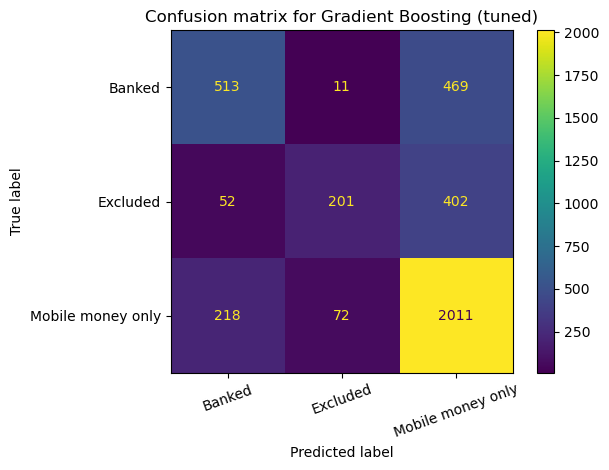

In [13]:
# Pick the model with the best cross validated macro F1 score.
best_model_name = comparison_df.loc[0, 'model']
best_pipeline = fitted_models[best_model_name]

best_predictions = best_pipeline.predict(X_test)

class_recalls = recall_score(
    y_test,
    best_predictions,
    labels=class_labels,
    average=None,
    zero_division=0
)

print('Chosen model:', best_model_name)
print('Excluded recall:', round(class_recalls[0], 4))
print('Mobile money only recall:', round(class_recalls[1], 4))
print('Banked recall:', round(class_recalls[2], 4))
print()
print(classification_report(y_test, best_predictions, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, best_predictions, xticks_rotation=20)
plt.title(f'Confusion matrix for {best_model_name}')
plt.tight_layout()
plt.savefig(figure_dir / 'adult_confusion_matrix.png', dpi=200)
plt.show()


## Subgroup error analysis

I do not want to turn this into a full fairness study, but it is still helpful to see whether the model behaves differently across a few important groups.

Here I am checking performance by **sex**, **education**, and **county**. I am also adding **Excluded recall** for each subgroup, because the excluded class is one of the hardest and most policy important parts of the prediction task.


In [14]:
# Build a helper for subgroup summaries.
def subgroup_metrics(df, group_col, group_name_col, min_rows=1):
    rows = []
    for group_name, group in df.groupby(group_col):
        if len(group) < min_rows:
            continue

        excluded_mask = group['actual'] == 'Excluded'
        if excluded_mask.sum() > 0:
            excluded_recall = recall_score(
                excluded_mask.astype(int),
                (group['predicted'] == 'Excluded').astype(int),
                zero_division=0
            )
        else:
            excluded_recall = np.nan

        rows.append({
            group_name_col: group_name,
            'rows': len(group),
            'accuracy': round(accuracy_score(group['actual'], group['predicted']), 4),
            'macro_f1': round(
                f1_score(group['actual'], group['predicted'], labels=class_labels, average='macro', zero_division=0),
                4
            ),
            'excluded_recall': round(excluded_recall, 4) if not np.isnan(excluded_recall) else np.nan
        })
    return pd.DataFrame(rows).sort_values('rows', ascending=False).reset_index(drop=True)

subgroup_df = X_test.copy()
subgroup_df['actual'] = y_test.values
subgroup_df['predicted'] = best_predictions
subgroup_df['sex_label'] = subgroup_df['sex'].map(sex_labels).fillna('Other or missing')
subgroup_df['education_label'] = subgroup_df['education'].map(education_labels).fillna('Missing or refused')
subgroup_df['county_name'] = subgroup_df['county'].map(county_labels).fillna(subgroup_df['county'].astype(str))

sex_subgroup_results = subgroup_metrics(subgroup_df, 'sex_label', 'group')
sex_subgroup_results

education_subgroup_results = subgroup_metrics(subgroup_df, 'education_label', 'group', min_rows=30)
education_subgroup_results

county_counts = subgroup_df['county_name'].value_counts()
top_counties = county_counts.head(10).index
county_subgroup_results = subgroup_metrics(
    subgroup_df[subgroup_df['county_name'].isin(top_counties)],
    'county_name',
    'group'
)
county_subgroup_results


,group,rows,accuracy,macro_f1,excluded_recall
0,County code 12,148,0.6757,0.5544,0.2273
1,County code 32,116,0.6293,0.4724,0.1429
2,County code 47,114,0.6404,0.4431,0.0000
3,County code 3,108,0.6759,0.5849,0.4231
4,County code 22,105,0.7238,0.6892,0.5000
5,County code 44,105,0.7143,0.6673,0.3824
6,County code 39,102,0.6667,0.5488,0.1818
7,County code 43,101,0.6832,0.5718,0.2381
8,County code 21,100,0.6300,0.5086,0.1429
9,County code 27,100,0.6100,0.5575,0.3000


## One robustness check

I want at least one simple robustness check so the project does not depend entirely on one sample definition.

Because the main analysis uses adults 18 and above, I will compare the chosen model on the **adult 18+ sample** against the same model on the broader cleaned sample that still includes ages 16 and 17.


In [15]:
# Compare the chosen model on adults only versus the broader cleaned sample.
from sklearn.base import clone

def evaluate_sample(df, sample_name):
    X_sample = df[selected_features].copy()
    y_sample = df['financial_access_profile'].copy()

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_sample,
        y_sample,
        test_size=0.20,
        random_state=42,
        stratify=y_sample
    )

    pipeline = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', clone(best_pipeline.named_steps['model']))
    ])

    pipeline.fit(X_train_s, y_train_s)
    preds = pipeline.predict(X_test_s)

    return {
        'sample': sample_name,
        'rows': len(df),
        'accuracy': round(accuracy_score(y_test_s, preds), 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_test_s, preds), 4),
        'macro_f1': round(f1_score(y_test_s, preds, average='macro'), 4)
    }

robustness_df = pd.DataFrame([
    evaluate_sample(adult_model_data, 'Adults 18+'),
    evaluate_sample(full_model_data, 'Cleaned full sample')
])
robustness_df
        


,sample,rows,accuracy,balanced_accuracy,macro_f1
0,Adults 18+,19741,0.6900,0.5658,0.5939
1,Cleaned full sample,20862,0.6925,0.6059,0.6364


## Interpret the model in a simple way

A good project should not only make predictions. It should also help explain what seems to matter.

To keep things simple, I am using **permutation importance**. The idea is straightforward. If shuffling one feature hurts the model a lot, that feature was probably important.

This does not prove causation, but it does give a useful ranking of which features matter most for the prediction task. I also want to remember that a model can look acceptable overall while still struggling on the **Excluded** class, so the interpretation should be read alongside the class-level recall results.


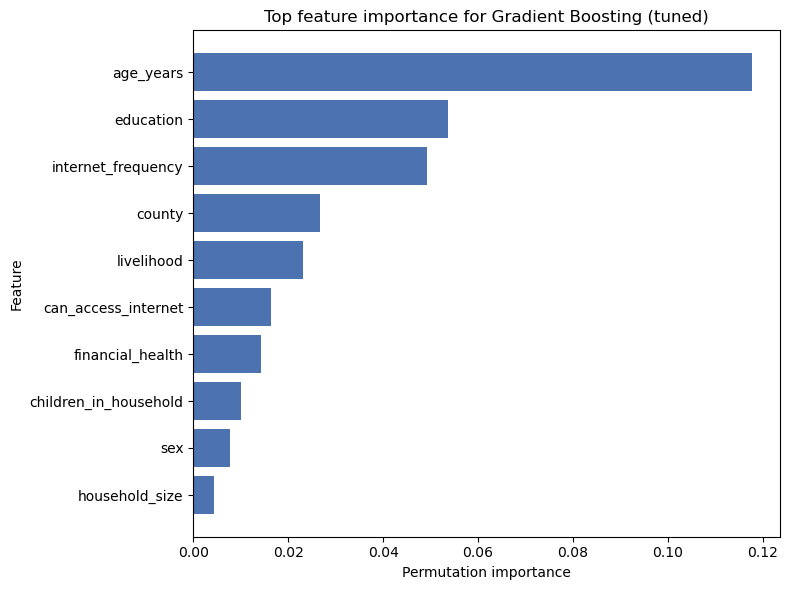

In [16]:
# Measure how much model performance drops when each feature is shuffled.
perm = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    scoring='f1_macro',
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

importance_df

# Plot the top features for an easy report ready visual.
top_importance = importance_df.head(10).sort_values('importance')

plt.figure(figsize=(8, 6))
plt.barh(top_importance['feature'], top_importance['importance'], color='#4C72B0')
plt.title(f'Top feature importance for {best_model_name}')
plt.xlabel('Permutation importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(figure_dir / 'adult_feature_importance.png', dpi=200)
plt.show()


## What the importance results mean for the project

This project is not just about model performance. It is also about understanding the kinds of factors that are associated with exclusion, mobile money use, and bank use in Kenya.

If features like internet access, education, county, or financial health show strong importance, that can help frame the discussion in a policy and development context. For example, the findings might support the idea that digital access, local context, and broader financial well-being still matter for inclusion.

Still, I need to be careful and treat these as **predictive patterns**, not proof that one factor directly causes another.


## Save the pieces I will need later

I want to save the model, the feature list, the comparison table, the feature-importance table, the subgroup summaries, the robustness check, and the numeric diagnostics so I can reuse them in the app and in the final report.
        


In [17]:
# Save the main outputs for later project steps.
comparison_df.to_csv(artifact_dir / 'final_model_comparison.csv', index=False)
importance_df.to_csv(artifact_dir / 'final_model_feature_importance.csv', index=False)
sex_subgroup_results.to_csv(artifact_dir / 'subgroup_performance_by_sex.csv', index=False)
education_subgroup_results.to_csv(artifact_dir / 'subgroup_performance_by_education.csv', index=False)
county_subgroup_results.to_csv(artifact_dir / 'subgroup_performance_by_county.csv', index=False)
robustness_df.to_csv(artifact_dir / 'robustness_check_18plus_vs_full.csv', index=False)
target_summary.to_csv(artifact_dir / 'weighted_target_summary_adults.csv')
top_excluded_counties.to_frame(name='weighted_excluded_percent').to_csv(artifact_dir / 'weighted_top_excluded_counties_adults.csv')
numeric_review.to_csv(artifact_dir / 'numeric_outlier_review.csv', index=False)
numeric_corr.to_csv(artifact_dir / 'numeric_correlations.csv')
joblib.dump(best_pipeline, artifact_dir / 'finaccess_final_pipeline.joblib')
joblib.dump(selected_features, artifact_dir / 'final_selected_features.joblib')

with open(artifact_dir / 'finaccess_final_model_name.txt', 'w', encoding='utf-8') as f:
    f.write(best_model_name)

print('Saved comparison table to:', artifact_dir / 'final_model_comparison.csv')
print('Saved feature importance table to:', artifact_dir / 'final_model_feature_importance.csv')
print('Saved sex subgroup summary to:', artifact_dir / 'subgroup_performance_by_sex.csv')
print('Saved education subgroup summary to:', artifact_dir / 'subgroup_performance_by_education.csv')
print('Saved county subgroup summary to:', artifact_dir / 'subgroup_performance_by_county.csv')
print('Saved robustness check to:', artifact_dir / 'robustness_check_18plus_vs_full.csv')
print('Saved weighted target summary to:', artifact_dir / 'weighted_target_summary_adults.csv')
print('Saved county exclusion summary to:', artifact_dir / 'weighted_top_excluded_counties_adults.csv')
print('Saved outlier review to:', artifact_dir / 'numeric_outlier_review.csv')
print('Saved numeric correlations to:', artifact_dir / 'numeric_correlations.csv')
print('Saved final pipeline to:', artifact_dir / 'finaccess_final_pipeline.joblib')
print('Saved selected features to:', artifact_dir / 'final_selected_features.joblib')
print('Saved model name to:', artifact_dir / 'finaccess_final_model_name.txt')
        


Saved comparison table to: artifacts\final_model_comparison.csv
Saved feature importance table to: artifacts\final_model_feature_importance.csv
Saved sex subgroup summary to: artifacts\subgroup_performance_by_sex.csv
Saved education subgroup summary to: artifacts\subgroup_performance_by_education.csv
Saved county subgroup summary to: artifacts\subgroup_performance_by_county.csv
Saved robustness check to: artifacts\robustness_check_18plus_vs_full.csv
Saved weighted target summary to: artifacts\weighted_target_summary_adults.csv
Saved county exclusion summary to: artifacts\weighted_top_excluded_counties_adults.csv
Saved outlier review to: artifacts\numeric_outlier_review.csv
Saved numeric correlations to: artifacts\numeric_correlations.csv
Saved final pipeline to: artifacts\finaccess_final_pipeline.joblib
Saved selected features to: artifacts\final_selected_features.joblib
Saved model name to: artifacts\finaccess_final_model_name.txt


## Limitations to remember

This project is useful, but it has limits.

- The **Banked** group includes people who may also use mobile money, so the classes are not fully symmetric.
- The target is based on **rule based grouping from survey responses**, not from observed transaction histories.
- The model shows **prediction and association**, not causation.
- The survey is **cross sectional**, so it gives one snapshot in time rather than tracking the same people over time.
- I used weights in the descriptive analysis, but the predictive modeling itself remains unweighted for simplicity.
- This notebook focuses on a narrower adult **core rails access profile**, not every broader concept of financial inclusion in the full survey.

These limits do not make the project weak. They just help keep the conclusions honest.


## Where I am now

At this point, I have a cleaner end-to-end notebook that also answers the main proposal comments directly.

I loaded the survey data, defined the adult sample, made the target construction explicit, documented dimensionality reduction and leakage avoidance, added weighted descriptive analysis, reviewed missingness and numeric outliers, added a numeric-only correlation check, compared models with stratified cross-validation, added a small Gradient Boosting tuning step, checked subgroup performance, ran a robustness check, interpreted the best model, and saved the final outputs. That keeps the notebook readable while making the project decisions much more explicit.
        
